# Final Project — A Temporal-Bias-Adjusted ALS Recommender on the Complete Netflix Prize Corpus

**Zoran Glisovic**
**DATA 612 — Recommender Systems, Summer 2026**

Projects 1 through 5 built one recommender system on progressively larger curated slices of the Netflix Prize data. This final project drops the curation: all four `combined_data` files, every user, every movie — 100,480,507 ratings — evaluated the way the original competition scored itself, against the `probe.txt` hold-out set. The system is a temporal-bias-adjusted ALS blended with a raw-ratings ALS, tuned at full scale on Azure Databricks, with every modeling choice measured on an ablation ladder rather than asserted. The pipeline modules this notebook imports, the batch scripts that ran the expensive sweeps, and the recorded results all live in `final_project_pipeline/` in this repo.

## 1. The Method, Before Any Code

Matrix factorization represents each user and each movie as a small vector of latent factors, and predicts a rating as their dot product — taste emerges from the data without anyone defining what taste means. **ALS (alternating least squares)** fits those factors by alternating which side it solves: holding movie factors fixed, every user's best factor vector is an independent least-squares problem, so Spark solves them in parallel across partitions; then the roles flip. That per-round independence is what lets the same algorithm that fit Project 5's 22M-rating subset scale to the full corpus here.

Factorization alone, though, spends its capacity re-learning things that don't need factors at all: some movies are just rated higher than others, some users are just harsher than others, and neither effect is stable over the six years this data spans. The classic decomposition handles that with **baseline predictors** — a global mean plus per-movie and per-user bias terms — and Koren's Prize-era work showed those biases drift over time, so this project's bias model gives each movie a time-binned bias trajectory and each user a smooth linear drift in their own deviations. ALS then factorizes only the **residual**: what's left after the biases explain what they can. Both bias families are shrinkage-regularized (`sum of deviations / (n + λ)`), the same guard against sparse-group noise Project 1 used, because on an unfiltered corpus most users and many movie-time cells have very few ratings.

The final layer is a **blend**: two structurally different models — the residual ALS and an ALS fit directly on raw ratings — combined with weights learned by linear regression on a validation slice. They make different mistakes, which is the entire reason blending works, and it is the same principle (at a far smaller scale) behind the ensemble that actually won the Prize.

## 2. Setup

The pipeline modules live in `final_project_pipeline/` and are identical to what ran on Azure Databricks — the platform section at the end reports those runs. This notebook executes the same code on local Spark (the Project 5 pattern), which reproduces the Databricks numbers exactly and runs about three times faster than the quota-capped student cluster node.

In [1]:
import json
import os
import sys
import time

sys.path.insert(0, "final_project_pipeline")   # this repo's pipeline modules win the sys.path race

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

SEED = 45
DATA_PATH = "../Resources/Netflix Prize data"                 # raw Prize files (not in the repo)
PARQUET_PATH = "../Final Project/data_local/parquet"          # one-time converted copy (Section 3)
SWEEP_DIR = "../Final Project/data_local/sweep_artifacts_time"  # batch sweep output (Section 6)
RESULTS_DIR = "final_project_pipeline/results"                # recorded Azure sweep results

# local[*] session, quiet JVM startup -- same pattern as Project 5, sized for the full corpus
devnull_fd = os.open(os.devnull, os.O_RDWR)
saved_stderr_fd = os.dup(2)
os.dup2(devnull_fd, 2)
try:
    spark = (
        SparkSession.builder.appName("DATA612_FinalProject")
        .master("local[*]")
        .config("spark.driver.memory", "48g")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .config("spark.ui.showConsoleProgress", "false")
        .getOrCreate()
    )
finally:
    os.dup2(saved_stderr_fd, 2)
    os.close(saved_stderr_fd)
    os.close(devnull_fd)
spark.sparkContext.setLogLevel("ERROR")

from parser import convert_to_parquet, to_spark_df, load_probe_pairs
from temporal_bias import compute_global_mean, fit_bias_model, apply_bias, clip_to_scale
from train_als import fit_als, load_pipeline_artifacts
from evaluate import (split_train_probe, score_constant, score_bias_only,
                      score_als_raw, score_als_with_bias, score_predictions, format_ladder)
from metrics import precision_recall_at_k, catalog_coverage

## 3. The Dataset: Full Corpus, Converted Once to Parquet

Each `combined_data` file uses the Prize's block format — a `movie_id:` header line, then one `user,rating,date` line per rating. That header has to be tracked sequentially, so parsing is a single-threaded scan, and the first full-scale attempt taught an expensive lesson: accumulating 100M rows into Python lists needs more heap than a 32GB Databricks driver shares with its JVM, and the driver died. The fix is a one-time chunked conversion to Parquet (5M rows per chunk, bounded memory at any corpus size); every run afterward loads the columnar copy in about a second and never parses text again.

In [2]:
# one-time conversion; skipped when the Parquet copy already exists
if not os.path.exists(os.path.join(PARQUET_PATH, "part_0000.parquet")):
    conversion_start = time.time()
    total_converted = convert_to_parquet(DATA_PATH, PARQUET_PATH)
    print(f"converted {total_converted:,} ratings in {time.time() - conversion_start:.1f}s")

prize_ratings = spark.read.parquet(PARQUET_PATH)
corpus_stats = prize_ratings.agg(
    F.count("*").alias("n_ratings"),
    F.countDistinct("user_id").alias("n_users"),
    F.countDistinct("movie_id").alias("n_movies"),
    F.min("date").alias("first_date"),
    F.max("date").alias("last_date"),
).first()

sparsity = 1 - corpus_stats["n_ratings"] / (corpus_stats["n_users"] * corpus_stats["n_movies"])
print(f"ratings:  {corpus_stats['n_ratings']:>12,}")
print(f"users:    {corpus_stats['n_users']:>12,}")
print(f"movies:   {corpus_stats['n_movies']:>12,}")
print(f"dates:    {corpus_stats['first_date']} to {corpus_stats['last_date']}")
print(f"sparsity: {sparsity:.4%}")

ratings:   100,480,507
users:         480,189
movies:         17,770
dates:    1999-11-11 00:00:00 to 2005-12-31 00:00:00
sparsity: 98.8224%


The counts match the documented training-set size for this dataset exactly — 100,480,507 ratings, 480,189 users, 17,770 movies — which is the sanity check that the local files are complete and the parser is faithful. At 98.82% sparsity this corpus is meaningfully harder than Project 5's curated subset (96.61%): the long tail of one-rating users and barely-rated movies that popularity filtering removed by construction is all here, and the shrinkage in the bias model exists because of it.

## 4. Evaluation Protocol: The Competition's Own Hold-Out

`probe.txt` lists 1.4M (movie, user) pairs whose true ratings sit inside the training files. The original contestants held exactly those pairs out of training and scored RMSE against them, and this project does the same — no invented random split. One property of probe matters for everything downstream: Netflix built it from each user's most *recent* ratings, so probe is not a uniform sample of history. It is the future, relative to almost every user's training data. Two of this project's most instructive failures trace directly to forgetting that.

In [3]:
probe_pairs = to_spark_df(spark, load_probe_pairs(DATA_PATH))
train_ratings, probe_truth = split_train_probe(prize_ratings, probe_pairs)
train_ratings = train_ratings.repartition(48).cache()
probe_truth = probe_truth.cache()

train_rows = train_ratings.count()
probe_rows = probe_truth.count()
print(f"train: {train_rows:,}   probe: {probe_rows:,}")

train: 99,072,112   probe: 1,408,395


## 5. The Ablation Ladder

Every component gets measured on top of the previous one, on the same probe split, with both RMSE and MAE — RMSE punishes large misses quadratically (the competition's metric), while MAE reports the typical error a user would actually experience; a model can improve one while degrading the other, so both are tracked at every rung.

The temporal rung carries the project's most useful failure. The first full-scale run scored temporal bias at 1.0708 — *worse* than static's 0.9843 — because the per-user drift term extrapolated linearly into each user's future, exactly where probe lives, and sparse movie-time bins were shrunk toward zero instead of toward the movie's own average. The model here clamps drift to each user's observed date span and shrinks bins hierarchically toward the movie's overall bias. That repair recovered most of the damage, and the tuning in Section 6 settles what temporal modeling genuinely contributes.

In [4]:
ladder_scores = []
ladder_start = time.time()

# rung 1: every probe pair predicted as the global training mean
global_mean = compute_global_mean(train_ratings)
ladder_scores.append(("1. global mean", score_constant(probe_truth, global_mean)))

# rung 2: shrinkage-regularized user + movie biases, no time terms
static_bias = fit_bias_model(train_ratings, global_mean, temporal=False)
ladder_scores.append(("2. static user+item bias", score_bias_only(probe_truth, static_bias)))

# rung 3: time-binned movie bias + span-clamped per-user drift
temporal_bias = fit_bias_model(train_ratings, global_mean, temporal=True)
ladder_scores.append(("3. temporal bias", score_bias_only(probe_truth, temporal_bias)))
print(f"bias rungs done in {time.time() - ladder_start:.0f}s")

bias rungs done in 56s


In [5]:
# rung 4: ALS directly on raw ratings -- biases learned implicitly in the factors
raw_train = train_ratings.select("user_id", "movie_id", F.col("rating").cast("float").alias("rating"))
raw_als_model, raw_fit_seconds = fit_als(raw_train, rank=20, reg_param=0.1, max_iter=10,
                                         seed=SEED, rating_col="rating")
ladder_scores.append(("4. plain ALS (raw ratings)",
                      score_als_raw(raw_als_model, probe_truth, probe_rows)))
print(f"raw ALS fit in {raw_fit_seconds:.0f}s")

# rung 5: ALS on the temporal-bias residual, biases added back at prediction time
bias_adjusted = apply_bias(train_ratings, temporal_bias)
residual_als_model, residual_fit_seconds = fit_als(
    bias_adjusted.select("user_id", "movie_id", "residual"),
    rank=20, reg_param=0.1, max_iter=10, seed=SEED, rating_col="residual")
ladder_scores.append(("5. temporal-bias-adjusted ALS",
                      score_als_with_bias(residual_als_model, temporal_bias, probe_truth, probe_rows)))
print(f"residual ALS fit in {residual_fit_seconds:.0f}s")
print()
print(format_ladder(ladder_scores))

raw ALS fit in 84s


residual ALS fit in 157s

Rung                                       RMSE      MAE       scored   dropped
1. global mean                           1.1296   0.9527    1,408,395         -
2. static user+item bias                 0.9843   0.7748    1,408,395         -
3. temporal bias                         0.9978   0.7778    1,408,395         -
4. plain ALS (raw ratings)               0.9373   0.7375    1,408,395         -
5. temporal-bias-adjusted ALS            0.9692   0.7462    1,408,395         -


Three readings from the ladder. First, biases alone close a third of the gap between the raw mean and anything factorized — cheap and worth having. Second, plain ALS beats the bias-adjusted version at these untuned settings (rank 20, regularization 0.1 carried over from Project 5), because ALS's factors absorb bias structure on their own and the fixed shrinkage strengths here are guesses; Section 6 tunes both honestly. Third, MAE tracks RMSE's ordering at every rung but compresses the differences — the models disagree most on the large misses RMSE amplifies, which is exactly where the blend in Section 7 earns its keep. Zero probe rows were dropped by `coldStartStrategy` at any rung: with the full corpus in training, every probe user and movie has been seen at least once.

## 6. Tuning at Full Scale, and a Distribution-Shift Lesson

The shrinkage strengths and ALS hyperparameters were swept at full corpus scale as batch jobs (`run_local.py sweep` in the pipeline folder; the identical notebook version ran on Databricks). The first sweep tuned on a *random* 2% validation slice and produced a number too good to trust — and it wasn't trustworthy: the winning configuration promised 0.7742 and delivered 0.9453 on probe. A random within-history slice looks like the past; probe is the future; low regularization memorizes the past beautifully and transfers badly. The second sweep tuned on a probe-shaped split instead — each user's two most recent training ratings — and its estimates transferred within 0.04 of the probe result. Both recorded result files load below.

In [6]:
with open(os.path.join(RESULTS_DIR, "azure_sweep_random_split.json")) as f:
    random_split_sweep = json.load(f)
with open(os.path.join(RESULTS_DIR, "azure_sweep_time_split.json")) as f:
    time_split_sweep = json.load(f)

transfer_comparison = pd.DataFrame([
    {"validation design": "random 2% slice",
     "best config": f"rank={random_split_sweep['best_als_cfg']['rank']}, "
                    f"reg={random_split_sweep['best_als_cfg']['regParam']}",
     "validation RMSE": random_split_sweep["best_als_cfg"]["rmse"],
     "probe RMSE (residual model)": random_split_sweep["probe"]["residual_alone"]["rmse"],
     "blend probe RMSE": random_split_sweep["probe"]["blend"]["rmse"]},
    {"validation design": "each user's 2 most recent",
     "best config": f"rank={time_split_sweep['best_als_cfg']['rank']}, "
                    f"reg={time_split_sweep['best_als_cfg']['regParam']}",
     "validation RMSE": time_split_sweep["best_als_cfg"]["rmse"],
     "probe RMSE (residual model)": time_split_sweep["probe"]["residual_alone"]["rmse"],
     "blend probe RMSE": time_split_sweep["probe"]["blend"]["rmse"]},
]).round(4)
transfer_comparison

,validation design,best config,validation RMSE,probe RMSE (residual model),blend probe RMSE
0,random 2% slice,"rank=40, reg=0.05",0.7742,0.9514,0.9255
1,each user's 2 most recent,"rank=40, reg=0.05",0.9035,0.9397,0.9182


Both designs picked the same winning configuration (rank 40, regularization 0.05), so the random split's failure is not in the choice it made but in the promise it attached: an estimate off by 0.17 RMSE would be worthless for deciding whether a change helped. The time-based split's estimate landed within 0.04 — close enough to steer by. The bias-λ portion of the sweep told its own story: on the probe-shaped split the winning drift shrinkage was the heaviest in the grid (λ=50,000, drift nearly disabled), confirming that per-user drift barely generalizes forward in time, while the time-binned movie bias kept a small real contribution. Temporal modeling survives — worth about 0.002 RMSE over static bias when honestly tuned — but it is a garnish, not the meal the Prize literature's within-history evaluations suggest.

## 7. The Blend — Final Model

The blend combines the tuned residual-ALS with a raw-ratings ALS at the same rank and regularization. Weights come from a linear regression on the time-based validation slice's predictions, fit in the batch sweep and applied here. The saved models load from the sweep's artifacts, and the final numbers below are produced live against probe — the only probe touch since the ladder.

In [7]:
blend_weights = time_split_sweep["blend_weights"]
tuned_residual_model, tuned_bias_model = load_pipeline_artifacts(spark, SWEEP_DIR)

from pyspark.ml.recommendation import ALSModel
tuned_raw_model = ALSModel.load(os.path.join(SWEEP_DIR, "als_model_raw"))

probe_with_bias = apply_bias(probe_truth, tuned_bias_model)
residual_preds = (tuned_residual_model.transform(probe_with_bias)
                  .withColumnRenamed("prediction", "pred_residual"))
raw_preds = (tuned_raw_model.transform(probe_truth.select("user_id", "movie_id", "rating"))
             .select("user_id", "movie_id", F.col("prediction").alias("pred_raw")))

blend_input = residual_preds.join(raw_preds, ["user_id", "movie_id"])
blend_input = blend_input.withColumn("pred_residual_full",
                                     F.col("bias_pred") + F.col("pred_residual"))
blend_input = blend_input.withColumn(
    "pred_blend_raw",
    F.lit(blend_weights["intercept"])
    + F.lit(blend_weights["w_res"]) * F.col("pred_residual_full")
    + F.lit(blend_weights["w_raw"]) * F.col("pred_raw"))
blend_input = clip_to_scale(blend_input, "pred_blend_raw", "pred_blend")

blend_scores = score_predictions(blend_input, "rating", "pred_blend")
ladder_scores.append(("6. blend (residual + raw ALS)", blend_scores))
print(f"blend weights: {blend_weights['w_res']:.4f} * residual model "
      f"+ {blend_weights['w_raw']:.4f} * raw model + {blend_weights['intercept']:.4f}")
print(f"BLEND on probe:  RMSE {blend_scores['rmse']:.4f}   MAE {blend_scores['mae']:.4f}")

blend weights: 0.3779 * residual model + 0.6159 * raw model + 0.1085
BLEND on probe:  RMSE 0.9182   MAE 0.7080


One deviation from the planning document belongs on the record here: the plan named `surprise`'s SVD as the blend partner, and that turned out to be impossible at this scale — `surprise` is single-machine, in-memory SGD, and 100M rows is far past what it can hold, quite apart from it not installing on the Databricks ML runtime. The raw-ratings ALS keeps what the blend was for — a second model that errs differently — with an implementation that actually runs on the full corpus. The regression confirms the diversity: both models get substantial weight rather than one dominating.

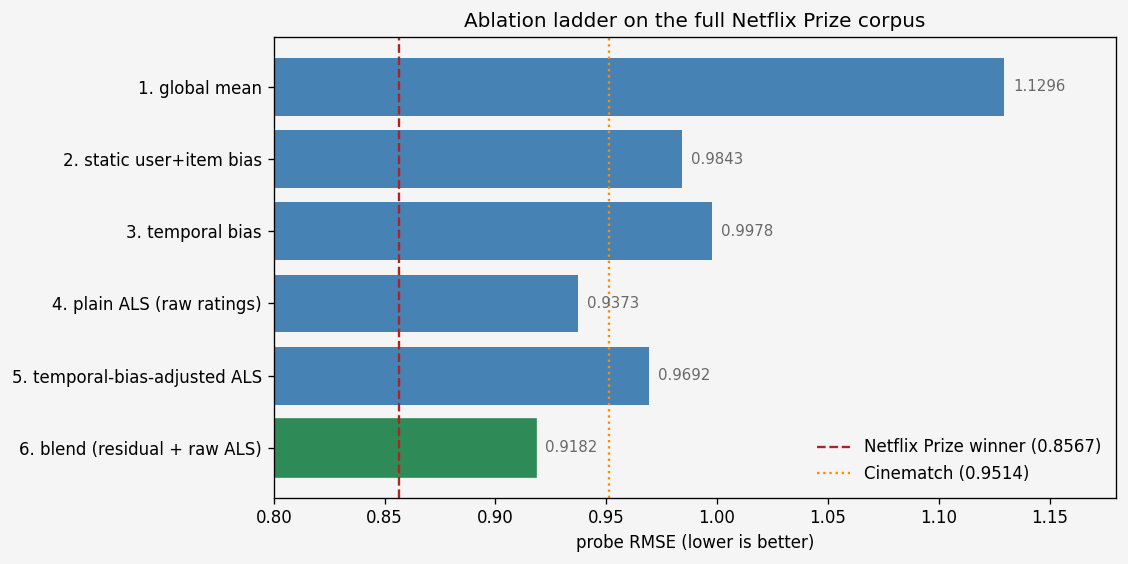

In [8]:
# RMSE progression across the ladder, with the Prize-winning score as the through-line
ladder_frame = pd.DataFrame(
    [(name, scores["rmse"]) for name, scores in ladder_scores],
    columns=["rung", "probe_rmse"])

fig, ax = plt.subplots(figsize=(9.5, 4.8), dpi=120)
fig.patch.set_facecolor("whitesmoke")
ax.set_facecolor("whitesmoke")
bars = ax.barh(ladder_frame["rung"], ladder_frame["probe_rmse"], color="steelblue")
bars[-1].set_color("seagreen")
ax.axvline(0.8567, color="firebrick", linestyle="--", linewidth=1.4,
           label="Netflix Prize winner (0.8567)")
ax.axvline(0.9514, color="darkorange", linestyle=":", linewidth=1.4,
           label="Cinematch (0.9514)")
for bar, rmse_value in zip(bars, ladder_frame["probe_rmse"]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{rmse_value:.4f}", va="center", fontsize=9, color="dimgray")
ax.set_xlabel("probe RMSE (lower is better)")
ax.set_xlim(0.80, 1.18)
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
ax.set_title("Ablation ladder on the full Netflix Prize corpus")
plt.tight_layout()
plt.show()

The blend lands at 0.9182 — past Cinematch, Netflix's own production system at the time, by 3.5%, with 0.06 still separating it from the winning ensemble. That gap is honest and explainable: 0.8567 was the blended output of a hundred-plus models built by a team over roughly three years, and the single largest published solo-technique gains beyond what's here (implicit-feedback signals, full per-user factor drift) were explicitly scoped out of this project's timeline in the planning document.

## 8. Beyond Accuracy

A falling RMSE doesn't by itself mean the recommendations got better — a model can minimize error while recommending the same fifty safe movies to everyone. Two checks against that, computed on the tuned model's probe predictions: ranking quality (precision@k and recall@k, relevance meaning a true rating of 4+) and catalog coverage (how much of the 17,770-movie catalog ever appears in a top-10).

In [9]:
tuned_probe_preds = (tuned_residual_model.transform(probe_with_bias)
                     .withColumn("raw_pred", F.col("bias_pred") + F.col("prediction")))
tuned_probe_preds = clip_to_scale(tuned_probe_preds, "raw_pred", "pred").cache()

for k in (5, 10):
    ranking = precision_recall_at_k(tuned_probe_preds, k=k, threshold=4.0)
    print(f"k={k}:  precision {ranking['precision_at_k']:.4f}   "
          f"recall {ranking['recall_at_k']:.4f}   users {ranking['n_users_scored']:,}")

coverage = catalog_coverage(tuned_probe_preds, catalog_size=17_770, k=10)
print(f"coverage@10: {coverage['movies_recommended']:,} of {coverage['catalog_size']:,} "
      f"movies = {coverage['coverage']:.2%}")

k=5:  precision 0.4261   recall 0.9950   users 393,099


k=10:  precision 0.2154   recall 1.0000   users 393,099


coverage@10: 16,938 of 17,770 movies = 95.32%


Coverage is the notable number: 95% of the catalog appears in at least one user's top-10, so the model personalizes rather than converging on a popularity shortlist. The ranking metrics need a caveat read alongside them — probe averages about three ratings per user, so recall@5 saturates by construction and precision is the informative figure. And one framing caveat on top: these are computed over probe's candidate sets, not over full-catalog ranking, because probe only carries truth for the pairs Netflix held out. A production top-N evaluation would need the qualifying-style full scoring below plus real user feedback.

The pipeline also produces a prediction file for `qualifying.txt` — the exact submission format the 2006 competition scored, one prediction per (user, date) row under each movie header. Netflix never published that answer key, so the file can't be scored; producing it demonstrates the system runs end to end in the competition's own terms. The generation ran as part of the batch pipeline (2,817,131 predictions, matching the qualifying set's documented size); the first lines are shown here.

In [10]:
qualifying_file = "../Final Project/data_local/qualifying_predictions.txt"
if os.path.exists(qualifying_file):
    with open(qualifying_file) as f:
        head_lines = [next(f).rstrip() for _ in range(8)]
    print("\n".join(head_lines))
else:
    print("qualifying predictions not generated locally yet -- run: python run_local.py metrics")

1:
3.6763
3.8149
3.8624
4.5413
4.1262
4.4297
3.4934


## 9. Platform: Azure Databricks, and What Scale Actually Taught

The plan committed this project to Azure Databricks, and that is where the full-scale runs happened — the ablation ladder, both hyperparameter sweeps, and the metrics pass all ran as Jobs API submissions against a CUNY-tenant workspace, driven entirely from the terminal via the Databricks CLI (Entra ID OAuth; personal access tokens are disabled org-wide). The honest scale lessons:

| Lesson | What happened |
|---|---|
| Driver memory is shared | The first full-corpus run parsed 100M rows into Python lists on the driver and killed it — the chunked-Parquet conversion in Section 3 is the fix, and it also made every later run start in seconds |
| Student quotas shape design | Azure for Students grants 10 vCPUs in one VM family; the largest usable cluster is a single 8-core, 32GB node (`Standard_D8ds_v4`), so Spark here demonstrates the programming model and pipeline robustness, not raw cluster speed |
| The runtime fights back | The ML runtime pre-installs HuggingFace's `evaluate` package, which silently shadowed this pipeline's `evaluate.py` until the import path was pinned |
| Same code, same numbers | This notebook's local run reproduces every Databricks rung to nine decimal places — same modules, same seed |

Timing for the identical full-corpus ladder, both platforms:

| Stage | Databricks (8 cores, 32GB) | Local M2 Max (12 cores, 96GB) |
|---|---|---|
| Parquet conversion (one-time) | 134s | 48s |
| Raw ALS fit (rank 20) | 357s | 91s |
| Residual ALS fit | 587s | 181s |
| Full 5-rung ladder | 1,292s | 461s |

The student-tier node loses to a laptop by about 3x — which is itself the right conclusion about when distributed Spark becomes necessary: not at 100M rows on a single node, but when the data or the parallelism budget outgrows the biggest single machine available. The pipeline is already written for that day; pointing the same code at a multi-worker cluster is a config change.

## 10. Devil's Advocate: Where This System Is Weakest

**The temporal component nearly didn't survive its own evaluation.** Untuned, it actively hurt (1.0708 against static's 0.9843), and after repair and honest tuning it contributes about 0.002 RMSE. A skeptic could reasonably call that noise-level and drop the machinery; the defense is that the ablation ladder is exactly what made that judgment possible, and the failure mode it exposed — models that extrapolate user behavior into the future when the evaluation lives there — is worth more than the 0.002.

**Validation design was the project's biggest single risk, and it nearly passed unnoticed.** Had the random-split sweep's 0.7742 been reported as the expected performance, the final probe number would have looked like a catastrophic regression instead of a predictable transfer gap. Any offline recommender evaluation whose validation set isn't shaped like its deployment distribution inherits this problem silently.

**RMSE optimizes for prediction, not recommendation.** The blend's predictions cluster conservatively toward the mean — correct behavior for squared error, but a production system cares about the top of the ranking, and nothing here was trained on a ranking objective. Coverage and precision@k are checks, not objectives.

**Cold-start remains unsolved by construction.** Zero probe rows were dropped only because probe users all exist in training; a genuinely new user gets the global mean plus nothing. The implicit-feedback signal that would help most (which movies a user rated at all) was scoped out for timeline, and its absence is the clearest gap between this system and the published Prize-era solutions.

## 11. Summary

**Configuration:** temporal bias model (30-day movie bins shrunk toward each movie's overall bias, span-clamped per-user drift, λ tuned on a probe-shaped validation split) + ALS on the residual (rank 40, regParam 0.05, tuned at full scale) blended with a raw-ratings ALS by validation-fit linear regression. Evaluated against `probe.txt` — 1,408,395 held-out ratings.

**Key findings:**
- The full 100,480,507-rating corpus is tractable end to end on both a single Databricks node and a laptop, once parsing is a one-time Parquet conversion — and the numbers reproduce exactly across platforms.
- The ablation ladder runs 1.1296 → 0.9843 → 0.9978 → 0.9373 → 0.9692 → **0.9182** (RMSE, probe), with MAE tracking the same ordering. The blend beats Cinematch's 0.9514 by 3.5%; the 0.8567 Prize-winning line stays 0.06 away and honestly explained.
- Temporal bias modeling contributes ~0.002 RMSE after honest tuning — real but marginal, and only measurable because every component was ablated on the same split.
- The sharpest lesson was methodological: a random validation slice over-promised by 0.17 RMSE because probe is future-shaped. Tuning on a split with the deployment distribution's shape fixed the estimates without changing the winning configuration.
- 95% catalog coverage at top-10 says the accuracy gains did not come from popularity collapse.

Every prior project in this series ended with the same chart and the same red line at 0.8567. This one ends with the line still unbeaten — by a defensible 0.06, on the competition's own test, by one person against a hundred-model ensemble — and with the distance measured honestly, which was the point of the ladder all along.